#### Importing necessary libraries

In [1]:
import pandas as pd # for data manipulation and analysis
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for data visualization
import numpy as np # for numerical computing
import glob # a framework for finding files and directories that match a specific pattern
import os # a gateway to access the operating system

## Phase 1: Performing ETL (Extract, Transform and Load)

In [2]:
'''Extracting data from multiple csv files'''
path = r'csv files'
all_files = glob.glob(os.path.join(path,'*.csv'))
df_from_each_file = [pd.read_csv(f) for f in all_files]
dataframe  = pd.concat(df_from_each_file,ignore_index = True)

#### Checking the number of entries and features

In [3]:
dataframe.shape

(186850, 6)

#### Viewing the General Information about the dataset

In [4]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 8.6+ MB


### Transforming and Loading the data  

#### Handling Missing Values

In [5]:
'''Checking the total number of missing values in each columns'''
dataframe.isnull().sum()

Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64

In [6]:
'''Dropping rows that contain missing values'''
dataframe = dataframe.dropna()

In [7]:
dataframe.isnull().sum()

Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
dtype: int64

#### Handling Duplicated rows

In [8]:
'''Calculating the total number of duplicated rows'''
dataframe.duplicated().sum()

618

In [9]:
'''Dropping duplicated rows and loading the data'''
dataframe = dataframe.drop_duplicates()

In [10]:
dataframe.duplicated().sum()

0

#### Filtering out incorrect entries
- while cleaning the data I noticed some rows contain their column names and which would be a problem while transforming some columns into numerical columns.

In [11]:
'''Filtering out Incorrect Entries'''
dataframe = dataframe[~((dataframe['Order ID']=='Order ID') & (dataframe['Product']== 'Product') & (dataframe['Quantity Ordered'] == 'Quantity Ordered')& (dataframe['Price Each']=='Price Each')& (dataframe['Order Date'] == 'Order Date') & (dataframe['Purchase Address'] == 'Purchase Address'))]

In [12]:
dataframe.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"


#### Changing the datatypes

In [13]:
dataframe = dataframe.astype({'Order ID': int, 'Quantity Ordered': int, 'Price Each': float})

In [14]:
dataframe.dtypes

Order ID              int32
Product              object
Quantity Ordered      int32
Price Each          float64
Order Date           object
Purchase Address     object
dtype: object

#### Changing the date datatype

In [15]:
'''Creating a new column for time and changing the datatype'''
dataframe['Order Time'] = dataframe['Order Date'].str.split(' ').str.get(1) 

In [16]:
dataframe['Order Date'] = dataframe['Order Date'].str.split(" ").str.get(0)

In [17]:
dataframe['Order Date'] = pd.to_datetime(dataframe['Order Date'], format = '%m/%d/%y')

In [18]:
dataframe['Order Time'] = pd.to_datetime(dataframe['Order Time'], format = '%H:%M').dt.time

In [19]:
dataframe.dtypes

Order ID                     int32
Product                     object
Quantity Ordered             int32
Price Each                 float64
Order Date          datetime64[ns]
Purchase Address            object
Order Time                  object
dtype: object

> __pd.to_datetime(...).dt.time returns Python datetime.time objects, not Pandas' internal datetime64 types, since datetime.time is a regular Python object, Pandas treats the entire column as object dtype.__

#### Creating new columns for postal code and purchase city

In [20]:
dataframe.head(2)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Order Time
0,176558,USB-C Charging Cable,2,11.95,2019-04-19,"917 1st St, Dallas, TX 75001",08:46:00
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07,"682 Chestnut St, Boston, MA 02215",22:30:00


In [21]:
'''Creating the purchase city column'''
dataframe['Purchase City'] = dataframe['Purchase Address'].str.split(',').str.get(1)

In [22]:
'''Creating the Postal code column'''
dataframe['Postal Code'] = dataframe['Purchase Address'].str.split(',').str.get(2)

In [23]:
dataframe['Purchase Address'] = dataframe['Purchase Address'].str.split(',').str.get(0)

In [24]:
dataframe.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Order Time,Purchase City,Postal Code
0,176558,USB-C Charging Cable,2,11.95,2019-04-19,917 1st St,08:46:00,Dallas,TX 75001
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07,682 Chestnut St,22:30:00,Boston,MA 02215
3,176560,Google Phone,1,600.00,2019-04-12,669 Spruce St,14:38:00,Los Angeles,CA 90001
4,176560,Wired Headphones,1,11.99,2019-04-12,669 Spruce St,14:38:00,Los Angeles,CA 90001
5,176561,Wired Headphones,1,11.99,2019-04-30,333 8th St,09:27:00,Los Angeles,CA 90001


#### Rearranging the columns

In [25]:
dataframe = dataframe[['Order ID', 'Product','Quantity Ordered', 'Price Each',"Order Date",'Order Time','Purchase Address','Purchase City','Postal Code']]
dataframe = dataframe.rename(columns = {'Price Each': 'Price($)'})

#### Sorting the Dataframe by the Order ID

In [26]:
dataframe.sort_values(by = 'Order ID', inplace =True)

In [27]:
dataframe.head()

,Order ID,Product,Quantity Ordered,Price($),Order Date,Order Time,Purchase Address,Purchase City,Postal Code
67547,141234,iPhone,1,700.00,2019-01-22,21:25:00,944 Walnut St,Boston,MA 02215
67548,141235,Lightning Charging Cable,1,14.95,2019-01-28,14:15:00,185 Maple St,Portland,OR 97035
67549,141236,Wired Headphones,2,11.99,2019-01-17,13:33:00,538 Adams St,San Francisco,CA 94016
67550,141237,27in FHD Monitor,1,149.99,2019-01-05,20:33:00,738 10th St,Los Angeles,CA 90001
67551,141238,Wired Headphones,1,11.99,2019-01-25,11:59:00,387 10th St,Austin,TX 73301


### Feature Engineering

In [28]:
'''Creating the sales month column'''
dataframe['Month'] = pd.to_datetime(dataframe['Order Date']).dt.month_name()

In [29]:
'''Creating the total sales column'''
dataframe['Total Sales($)'] = (dataframe['Quantity Ordered'] * dataframe['Price($)']).astype(float)

#### Grouping products into broader categories

In [30]:
'''Checking inventory'''
display(dataframe['Product'].value_counts())
len((dataframe['Product'].value_counts()).index)

Product
USB-C Charging Cable          21859
Lightning Charging Cable      21610
AAA Batteries (4-pack)        20612
AA Batteries (4-pack)         20558
Wired Headphones              18849
Apple Airpods Headphones      15525
Bose SoundSport Headphones    13298
27in FHD Monitor               7498
iPhone                         6840
27in 4K Gaming Monitor         6225
34in Ultrawide Monitor         6174
Google Phone                   5522
Flatscreen TV                  4794
Macbook Pro Laptop             4721
ThinkPad Laptop                4126
20in Monitor                   4098
Vareebadd Phone                2065
LG Washing Machine              666
LG Dryer                        646
Name: count, dtype: int64

19

In [31]:
'''Creating a Mapping dictionary'''
Category = {'USB-C Charging Cable':'Cable', 'Lightning Charging Cable': 'Cable', 'AAA Batteries (4-pack)':'Battery',
           'AA Batteries (4-pack)':'Battery','Wired Headphones':'Headphone', 'Apple Airpods Headphones':'Headphone','Bose SoundSport Headphones':'Headphone',
           '27in FHD Monitor':'Monitor','iPhone':'Phone', '27in 4K Gaming Monitor':'Monitor', '34in Ultrawide Monitor':'Monitor',
           'Google Phone':'Phone','Flatscreen TV':'TV', 'Macbook Pro Laptop':'Laptop','ThinkPad Laptop':'Laptop','20in Monitor':'Monitor',
           'Vareebadd Phone':'Phone','LG Washing Machine': 'Washing Machine','LG Dryer': 'Dryer'}
len(Category)

19

In [32]:
'''Creating a new column called Product Category'''
dataframe['Product'] = dataframe['Product'].str.strip()
dataframe['Product Category'] = dataframe['Product'].map(Category)

In [33]:
'''Rearranging the dataset columns'''
dataframe = dataframe[['Order ID', 'Product','Product Category','Quantity Ordered', 'Price($)','Total Sales($)',"Order Date",'Order Time','Month','Purchase Address','Purchase City','Postal Code']]

In [34]:
dataframe.head(3)

,Order ID,Product,Product Category,Quantity Ordered,Price($),Total Sales($),Order Date,Order Time,Month,Purchase Address,Purchase City,Postal Code
67547,141234,iPhone,Phone,1,700.00,700.00,2019-01-22,21:25:00,January,944 Walnut St,Boston,MA 02215
67548,141235,Lightning Charging Cable,Cable,1,14.95,14.95,2019-01-28,14:15:00,January,185 Maple St,Portland,OR 97035
67549,141236,Wired Headphones,Headphone,2,11.99,23.98,2019-01-17,13:33:00,January,538 Adams St,San Francisco,CA 94016


In [35]:
'''Confirming the newly added columns doesn't have missing values'''
dataframe.isnull().sum()

Order ID            0
Product             0
Product Category    0
Quantity Ordered    0
Price($)            0
Total Sales($)      0
Order Date          0
Order Time          0
Month               0
Purchase Address    0
Purchase City       0
Postal Code         0
dtype: int64

### __Univariate Analysis__

#### Visualizing the distribution of numerical columns

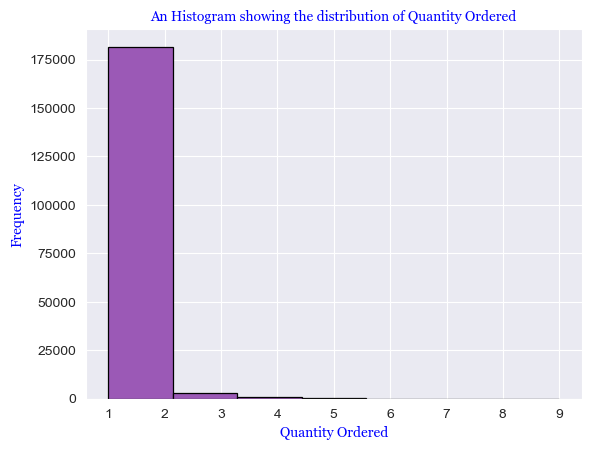

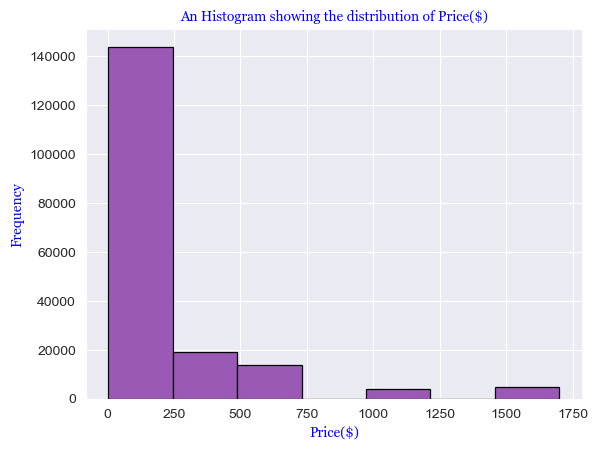

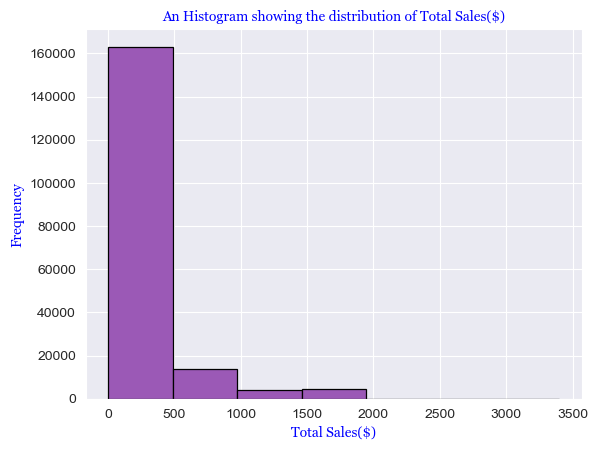

In [36]:
for column in dataframe.columns:
    if column == 'Order ID':
        continue
    if dataframe[column].dtype == int or dataframe[column].dtype == float:
        sns.set_style('darkgrid')
        plt.hist(dataframe[column], bins = 7, color = '#9B59B6', edgecolor = 'black', linewidth = 0.9)
        plt.title(f'An Histogram showing the distribution of {column}', color = 'Blue', fontdict = {'font':'Georgia'})
        plt.xlabel(column,color = 'Blue', fontdict = {'font': 'Georgia'})
        plt.ylabel('Frequency',color = 'Blue', fontdict = {'font': 'Georgia'})
        plt.show()

####  __Actionable Insights__
1. Sales data shows that the vast majority of orders contain only 1 to 2 units per product.
2. The majority of products purchased fall below $250, indicating that customers favor low to mid-range priced items.

3. While individual high-value orders exist, most total sales per order do not exceed $500.

#### Visualizing the distribution of categorical data

In [37]:
Ser = dataframe['Order Date'].value_counts().reset_index()
display(Ser)
Ser[Ser['count'] == Ser['count'].max()]

,Order Date,count
0,2019-12-17,879
1,2019-12-23,868
2,2019-12-13,857
3,2019-12-29,840
4,2019-12-16,825
...,...,...
361,2019-01-08,283
362,2019-01-14,281
363,2019-01-31,277
364,2019-01-23,277


,Order Date,count
0,2019-12-17,879


> __Conclusion: 17th of December is the most recurring date__

In [38]:
for column in dataframe.columns:
    if column == 'Postal Code': 
        continue
    if dataframe[column].dtype == object:
        Ser = dataframe[column].value_counts().reset_index()
        
        '''Displaying 5 samples from the data distribution'''
        
        display(Ser)

        print('MAXIMUM')
        display(Ser[Ser['count'] == Ser['count'].max()])
    

,Product,count
0,USB-C Charging Cable,21859
1,Lightning Charging Cable,21610
2,AAA Batteries (4-pack),20612
3,AA Batteries (4-pack),20558
4,Wired Headphones,18849
5,Apple Airpods Headphones,15525
6,Bose SoundSport Headphones,13298
7,27in FHD Monitor,7498
8,iPhone,6840
9,27in 4K Gaming Monitor,6225


MAXIMUM


,Product,count
0,USB-C Charging Cable,21859


,Product Category,count
0,Headphone,47672
1,Cable,43469
2,Battery,41170
3,Monitor,23995
4,Phone,14427
5,Laptop,8847
6,TV,4794
7,Washing Machine,666
8,Dryer,646


MAXIMUM


...

MAXIMUM


,Purchase Address,count
0,640 West St,14
1,753 Cedar St,14
2,594 6th St,14
3,986 7th St,14
4,732 Highland St,14
5,2 Hill St,14


,Purchase City,count
0,San Francisco,44662
1,Los Angeles,29564
2,New York City,24847
3,Boston,19901
4,Atlanta,14863
5,Dallas,14797
6,Seattle,14713
7,Portland,12449
8,Austin,9890


MAXIMUM


,Purchase City,count
0,San Francisco,44662


#### __Computing Statistical Summary for both numerical and categorical columns.__ 

In [39]:
'''Generating Statistical Summary for numerical columns'''
np.round(dataframe.describe(include = [int, float]),2)

,Order ID,Quantity Ordered,Price($),Total Sales($)
count,185686.00,185686.00,185686.00,185686.00
mean,230411.38,1.12,184.52,185.61
std,51511.72,0.44,332.84,333.03
min,141234.00,1.00,2.99,2.99
25%,185833.25,1.00,11.95,11.95
50%,230354.50,1.00,14.95,14.95
75%,275028.75,1.00,150.00,150.00
max,319670.00,9.00,1700.00,3400.00


In [40]:
'''Generating statistical for categorical columns'''
dataframe.loc[:,['Product','Product Category',"Order Date",'Order Time','Month','Purchase Address','Purchase City','Postal Code']].agg(func = ['mode']).dropna()

,Product,Product Category,Order Date,Order Time,Month,Purchase Address,Purchase City,Postal Code
,mode,mode,mode,mode,mode,mode,mode,mode
0,USB-C Charging Cable,Headphone,2019-12-17,11:58:00,December,2 Hill St,San Francisco,CA 94016


In [41]:
'''This displays the frequency of each categorical columns'''
dataframe.loc[:,['Product','Product Category',"Order Date",'Order Time','Month','Purchase Address','Purchase City','Postal Code']].count()

Product             185686
Product Category    185686
Order Date          185686
Order Time          185686
Month               185686
Purchase Address    185686
Purchase City       185686
Postal Code         185686
dtype: int64

### __Bivariate/Multivariate Analysis__

#### Identifying Relationships between the numerical columns

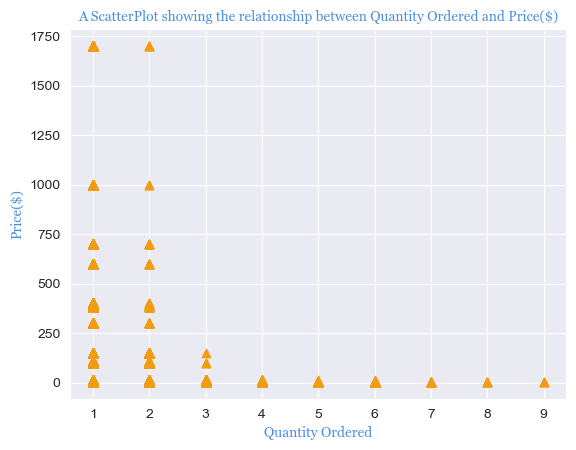

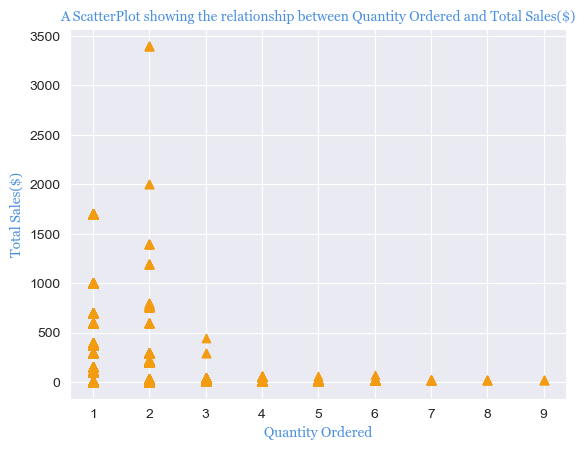

In [42]:
'''Checking the relationship between Quantity ordered Column and other numerical colums '''
column = 'Quantity Ordered'
for column2 in dataframe.columns:
    if column2 == 'Order ID' or column == column2:
        continue
    if dataframe[column].dtype == int or dataframe[column].dtype == float:
        if dataframe[column2].dtype == int or dataframe[column2].dtype == float:
            sns.set_style('darkgrid')
            
            plt.scatter(dataframe[column], dataframe[column2], marker = '^', color = '#F39C12', alpha = 1 )
            plt.title(f'A ScatterPlot showing the relationship between {column} and {column2}', color ='#4A90E2', fontdict = {'font':'Georgia'})
            plt.xlabel(column, color = '#4A90E2', fontdict = {'font':'Georgia'})
            plt.ylabel(column2, color = '#4A90E2', fontdict = {'font':'Georgia'})
            plt.show()
    

### __Actionable Insights__
1. The weak negative correlation between product price and quantity ordered indicates that higher-priced items are typically purchased in smaller quantities.

2. The weak inverse relationship between quantity ordered and total sales suggests that high-quantity purchases do not always translate into higher revenue.

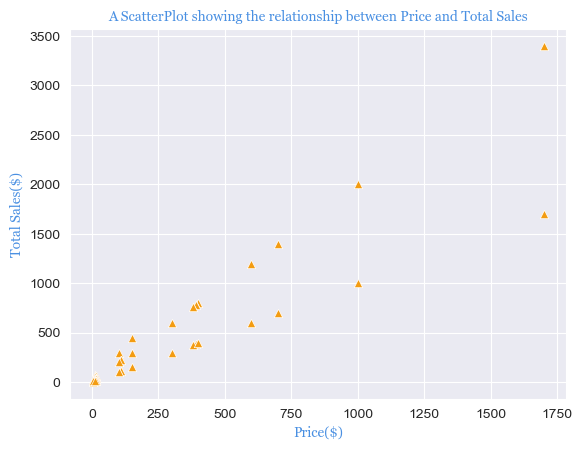

In [43]:
'''Checking the Relationship between Price and Total sales '''
sns.set_style('darkgrid')
sns.scatterplot(x = 'Price($)', y = 'Total Sales($)', data = dataframe, marker = '^',color = '#F39C12')
plt.title('A ScatterPlot showing the relationship between Price and Total Sales',color = '#4A90E2', fontdict = {'font':'Georgia'})
plt.xlabel('Price($)', color = '#4A90E2', fontdict = {'font':'Georgia'})
plt.ylabel('Total Sales($)', color = '#4A90E2', fontdict = {'font':'Georgia'})
plt.show()

>__Actionable Insight:__ A strong positive correlation between product price and total sales indicates that high-priced items significantly contribute to revenue

#### Creating a correlation matrice to Quantify the relationships

In [44]:
dataframe.corr(numeric_only = True)

,Order ID,Quantity Ordered,Price($),Total Sales($)
Order ID,1.000000,0.000739,-0.002854,-0.002946
Quantity Ordered,0.000739,1.000000,-0.148422,-0.139564
Price($),-0.002854,-0.148422,1.000000,0.999202
Total Sales($),-0.002946,-0.139564,0.999202,1.000000


#### Performing Groupby Analysis

##### Finding Total Sales made for each month throughout the year

In [45]:
Sales_per_month = dataframe.groupby('Month')['Total Sales($)'].sum().reset_index()
Sales_per_month

,Month,Total Sales($)
0,April,3389217.98
1,August,2241083.37
2,December,4608295.70
3,February,2200078.08
4,January,1821413.16
5,July,2646461.32
6,June,2576280.15
7,March,2804973.35
8,May,3150616.23
9,November,3197875.05


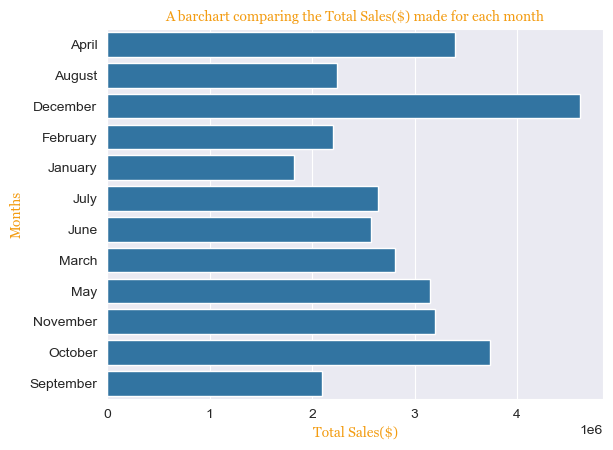

In [46]:
sns.set_style('darkgrid')
sns.barplot(y = 'Month', x = 'Total Sales($)', data = Sales_per_month)
plt.title('A barchart comparing the Total Sales($) made for each month', color ='#F39C12', fontdict = {'font': 'Georgia'})
plt.ylabel('Months',color = '#F39C12', fontdict = {'font': 'Georgia'})
plt.xlabel('Total Sales($)',color = '#F39C12', fontdict = {'font':'Georgia'})
plt.show()

>__Conclusion: The highest Sales was made in December__

##### Finding the total sales from each product

,Product,Total Sales($)
0,20in Monitor,453818.74
1,27in 4K Gaming Monitor,2433147.61
2,27in FHD Monitor,1131074.59
3,34in Ultrawide Monitor,2352898.08
4,AA Batteries (4-pack),106041.60
5,AAA Batteries (4-pack),92648.14
6,Apple Airpods Headphones,2345550.00
7,Bose SoundSport Headphones,1342865.70
8,Flatscreen TV,1443900.00
9,Google Phone,3317400.00


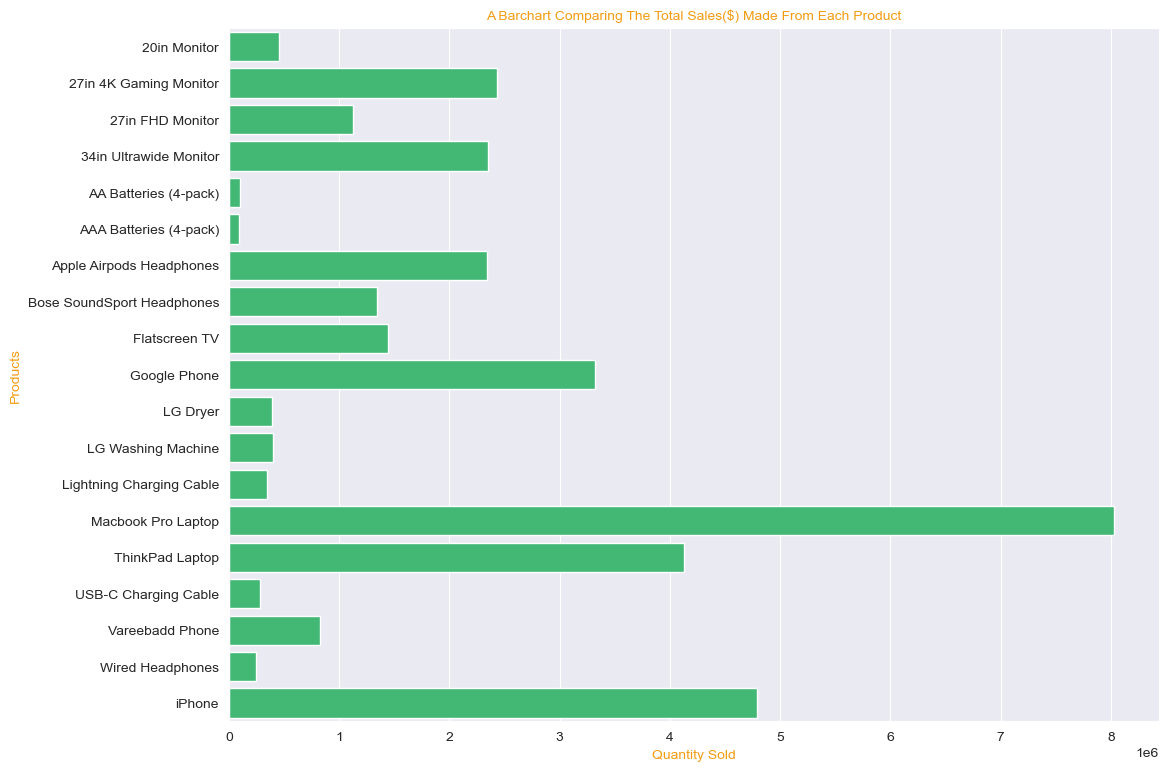

In [47]:
df = dataframe.groupby('Product')['Total Sales($)'].sum().reset_index()

display(df)
plt.figure(figsize = (12,9))
sns.set_style('darkgrid')

sns.barplot(x = 'Total Sales($)', y ='Product',data = df, color ='#2ECC71' )
plt.title('A Barchart Comparing The Total Sales($) Made From Each Product',color = '#F39C12', fontdict = {'font': 'Sans Serif'})
plt.ylabel('Products',color = '#F39C12', fontdict = {'font': 'Sans Serif'})
plt.xlabel('Quantity Sold',color = '#F39C12', fontdict = {'font': 'Sans Serif'})
plt.show()

> __Actionable Insight:__ The MacBook Pro Laptop generated the highest total sales, contributing approximately $8,032,500 to overall revenue. This highlights it as a top-performing product.

#### Creating Pivot Tables for deeper insights

In [48]:
'''Checking the date the highest units of products was sold'''
Sales_date = dataframe.pivot_table(index = ['Order Date'] ,values = ['Quantity Ordered'] ,aggfunc = 'sum').reset_index()
display(Sales_date)
Sales_date[Sales_date['Quantity Ordered'] == Sales_date['Quantity Ordered'].max()]

,Order Date,Quantity Ordered
0,2019-01-01,343
1,2019-01-02,367
2,2019-01-03,330
3,2019-01-04,329
4,2019-01-05,355
...,...,...
361,2019-12-28,928
362,2019-12-29,953
363,2019-12-30,925
364,2019-12-31,884


,Order Date,Quantity Ordered
350,2019-12-17,1042


> __Actionable Insight:__ Sales data reveals that December 17th, 2019, recorded the highest number of product units sold — totaling 1,042 units in a single day. This highlights a significant spike in customer demand during the third week of December, likely due to pre-Christmas shopping behavior.

In [49]:
'''Finding which city sold the most product'''
city = dataframe.pivot_table(index = ['Purchase City'], values = ['Quantity Ordered'], aggfunc = 'sum').reset_index()
display(city)

,Purchase City,Quantity Ordered
0,Atlanta,16584
1,Austin,11137
2,Boston,22494
3,Dallas,16707
4,Los Angeles,33247
5,New York City,27903
6,Portland,14037
7,San Francisco,50169
8,Seattle,16534


>__Actionable Insight:__ San Francisco recorded the highest product sales with a total of 50,169 units sold.

In [50]:
'''Finding the most sold product'''
prod  = dataframe.groupby('Product')['Quantity Ordered'].sum().reset_index()
prod

,Product,Quantity Ordered
0,20in Monitor,4126
1,27in 4K Gaming Monitor,6239
2,27in FHD Monitor,7541
3,34in Ultrawide Monitor,6192
4,AA Batteries (4-pack),27615
5,AAA Batteries (4-pack),30986
6,Apple Airpods Headphones,15637
7,Bose SoundSport Headphones,13430
8,Flatscreen TV,4813
9,Google Phone,5529


>__Actionable Insight:__ AAA Batteries (4-pack) emerged as the most sold product in the year, with a total of 30,986 units sold. This high sales volume is likely driven by its low price point of $2.99, making it a frequent impulse or add-on purchase.

#### Time Series Analysis

##### Total Sales Trend

In [51]:
df = dataframe.groupby('Order Date')['Total Sales($)'].sum().reset_index()

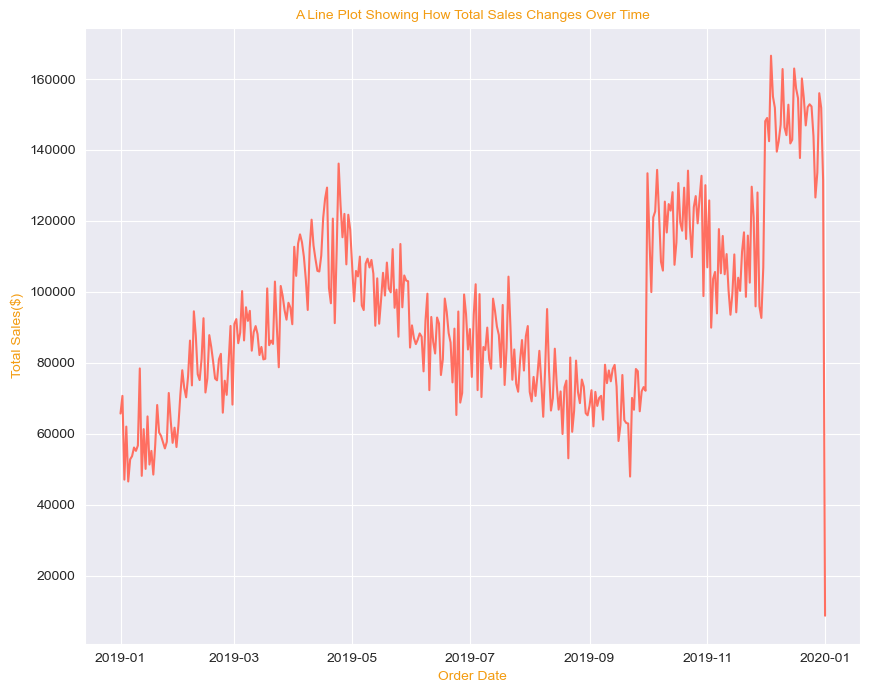

In [52]:
sns.set_style('darkgrid')
plt.figure(figsize = (10,8))
plt.title('A Line Plot Showing How Total Sales Changes Over Time', color = '#F39C12', fontdict = {'font': 'Sans Serif'} )
sns.lineplot(x = 'Order Date', y ='Total Sales($)', data = df, color = '#FF6F61')
plt.xlabel('Order Date',color = '#F39C12', fontdict = {'font': 'Sans Serif'})
plt.ylabel('Total Sales($)',color = '#F39C12', fontdict = {'font': 'Sans Serif'})
plt.show()

#### __Actionable Insights__
1. __Sales Grew Steadily Early in the Year:__ From january to April/May 2019, there is a clear upward trend in total sales and this suggests a period of increasing customer activity or marketing effectiveness.
   
2.  __Mid-Year Sales Fluctuated:__ From May to September 2019, the sales trend shows noticeable fluctuations and moderate decline.This could indicate seasonal changes, market saturation, or less promotional activity.
3. __Major Surge in Late 2019:__ Around October to December, there's a sharp increase in total sales.
This likely reflects festive season sales spikes, especially Christmas. Sales peak at over $160,000, the highest in the dataset.





#### Identifying Weekly Seasonality

In [53]:
dataframe['Order Day'] = pd.to_datetime(dataframe['Order Date']).dt.day_name()
Weekly_Sales_pattern = dataframe.pivot_table(index = ['Order Day'], columns= ['Month'], values = ['Total Sales($)'], aggfunc = 'sum')

In [54]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
Weekly_Sales_pattern = Weekly_Sales_pattern.reindex(day_order)

In [55]:
Weekly_Sales_pattern

Total Sales($)                                              \
Month              April     August   December   February    January   
Order Day                                                              
Monday         530733.53  287826.00  763046.04  296587.76  221510.73   
Tuesday        566937.52  296972.04  746976.39  312733.02  307724.91   
Wednesday      496453.95  286784.75  619811.91  344234.80  299602.68   
Thursday       483096.33  365073.84  580891.33  294407.09  277088.02   
Friday         439725.28  340701.01  591460.05  323582.17  246594.04   
Saturday       434600.24  374703.11  569631.00  319373.02  223077.00   
Sunday         437671.13  289022.62  736478.98  309160.22  245815.78   

                                                                             \
Month           July       June      March        May   November    October   
Order Day                                                                     
Monday     432366.64  303826.90  379742.13  383186.78  435615.07  491314.64   
Tuesday    410145.99  372019.42  374404.70  403130.44  413303.23  616416.06   
Wednesday  436390.05  337248.97  355449.04  521868.18  432245.35  552322.15   
Thursday   353419.25  329810.88  355287.57  502974.18  411776.95  595909.38   
Friday     296177.85  355291.68  467034.48  503046.53  531196.73  481188.00   
Saturday   362245.08  441695.77  453416.61  399642.91  545262.03  491660.72   
Sunday     355716.46  436386.53  419638.82  436767.21  428475.69  505966.91   

                      
Month      September  
Order Day             
Monday     351831.99  
Tuesday    265511.68  
Wednesday  304411.53  
Thursday   284028.91  
Friday     277644.44  
Saturday   284888.09  
Sunday     326149.05

In [56]:
sales_mean = np.round(Weekly_Sales_pattern.mean(axis = 1)).reset_index()
sales_mean.rename(columns  = {0:'Average Sales'}, inplace = True)
sales_mean

,Order Day,Average Sales
0,Monday,406466.0
1,Tuesday,423856.0
2,Wednesday,415569.0
3,Thursday,402814.0
4,Friday,404470.0
5,Saturday,408350.0
6,Sunday,410604.0


In [57]:
sales_mean[sales_mean['Average Sales'] == sales_mean['Average Sales'].min()]

,Order Day,Average Sales
3,Thursday,402814.0


In [58]:
sales_mean[sales_mean['Average Sales'] == sales_mean['Average Sales'].max()]

,Order Day,Average Sales
1,Tuesday,423856.0


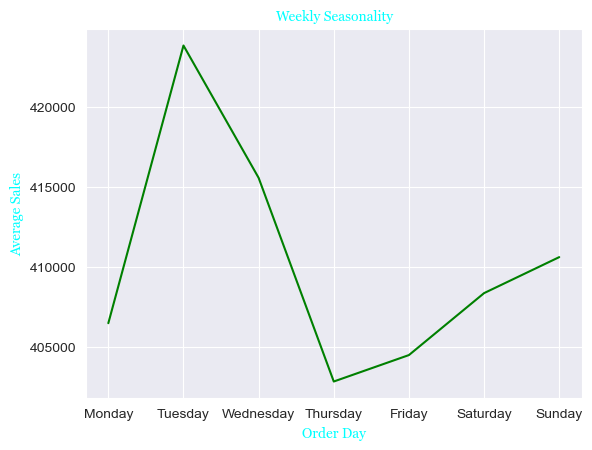

In [59]:
sns.set_style('darkgrid')
plt.plot(sales_mean['Order Day'], sales_mean['Average Sales'], color = 'green')

plt.title('Weekly Seasonality', color = 'cyan', fontdict = {'font':'Georgia'})
plt.xlabel('Order Day',color = 'cyan', fontdict = {'font':'Georgia'})
plt.ylabel('Average Sales',color = 'cyan', fontdict = {'font':'Georgia'})
plt.show()

#### __Actionable Insight__
1. Sales performance is consistently lowest on Thursdays, as shown by the weekly average across all months.

2. Tuesdays consistently record the highest average sales, indicating a peak in customer activity and purchasing demand on that day.

### Finding what products are often sold together
- To do, i would find out order ids that appeared more than once then group the dataset by order id.

In [60]:
df = dataframe[dataframe.duplicated(subset = 'Order ID', keep = False)]

In [61]:
'''A function to convert the product list into a single string'''
from functools import reduce
def func (arg):
    result = reduce(lambda x, y: x +","+y, arg)
    return result

In [62]:
df= df.groupby('Order ID')['Product'].transform(func)

In [63]:
df.sample(5)

111465        Google Phone,USB-C Charging Cable
174957    20in Monitor,Lightning Charging Cable
138053                  iPhone,Wired Headphones
37626         USB-C Charging Cable,Google Phone
68336                   Wired Headphones,iPhone
Name: Product, dtype: object

In [64]:
df = df.reset_index()

In [65]:
'''Finding the products often sold together'''
df = df.groupby('Product')['Product'].value_counts().reset_index()

In [66]:
df.sample(5)

,Product,count
53,"34in Ultrawide Monitor,AA Batteries (4-pack)",28
154,"Flatscreen TV,27in FHD Monitor",8
259,"ThinkPad Laptop,27in FHD Monitor",8
146,"Bose SoundSport Headphones,USB-C Charging Cabl...",9
204,"LG Dryer,Flatscreen TV",2


In [67]:
df[df['count'] == df['count'].max()]

,Product,count
375,"iPhone,Lightning Charging Cable",1328


> __Actionable Insight:__ iPhone and Lightning Charging Cable are products often sold together.

#### Finding the appropriate time for advertisement

In [126]:
Ser = dataframe.pivot_table(index = ['Order Time'] ,values = ['Order ID'], aggfunc = 'nunique').reset_index()
display(Ser.sample(5))
Ser[Ser['Order ID'] == Ser['Order ID'].max()]

,Order Time,Order ID
342,05:42:00,21
474,07:54:00,76
1217,20:17:00,203
205,03:25:00,12
399,06:39:00,42


,Order Time,Order ID
718,11:58:00,233
805,13:25:00,233


In [127]:
Ser['Order Time'] = pd.to_datetime(Ser['Order Time'], format='%H:%M:%S', errors='coerce')

In [128]:
Ser['Order Time'] = Ser['Order Time'].dt.strftime('%H:00')

In [129]:
Ser = Ser.groupby('Order Time')['Order ID'].sum().reset_index() 

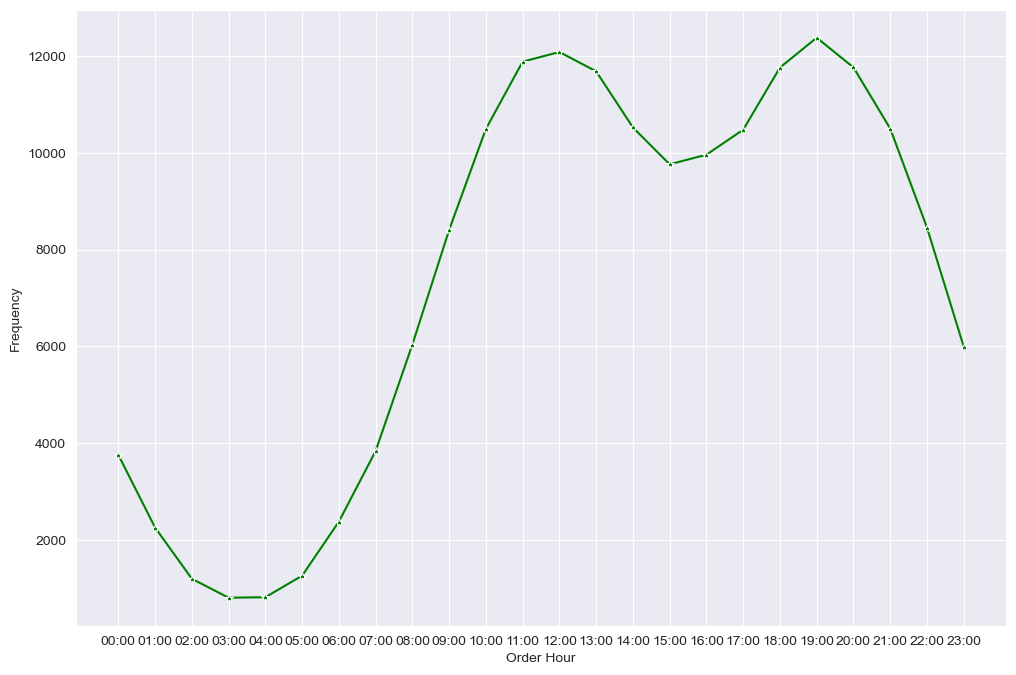

In [133]:
sns.set_style('darkgrid')
plt.figure(figsize = (12, 8))
sns.lineplot( x = 'Order Time', y = 'Order ID', 
      data = Ser , marker = '*', color  = 'green')
plt.xlabel('Order Hour')
plt.ylabel ('Frequency')
plt.show()

>__The peak number of orders occurs around 11:58 AM and 13:25PM making both best time to run ads for general products__

## Phase 2: Visualization

#### Using heatmap to display correlation matrice

In [69]:
correlation = dataframe.corr(numeric_only = True)

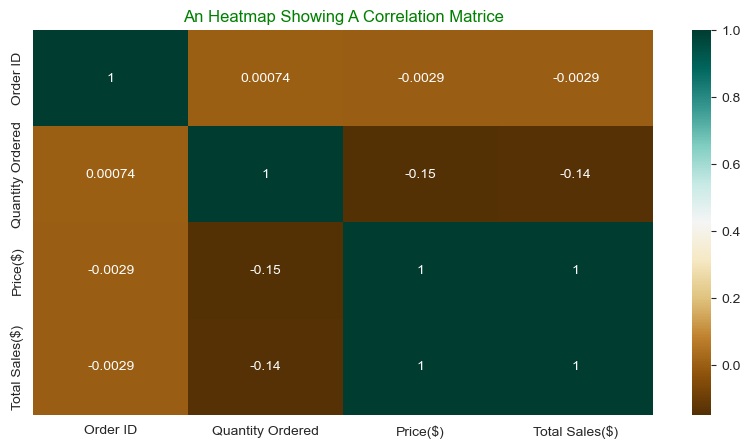

In [70]:
plt.figure(figsize=(10,5))
sns.heatmap(correlation,cmap= "BrBG",annot=True)
plt.title('An Heatmap Showing A Correlation Matrice', color = 'Green' )
plt.show()

#### __Actionable Insights__
1. The heatmap shows a very strong positive correlation (0.999) between Price and Total Sales($), confirming that higher-priced products contribute significantly to revenue.

2. In contrast, there is a weak negative correlation between Quantity Ordered and both Price($) and Total Sales, indicating that lower-priced products are more likely to be purchased in higher quantities. This suggests an opportunity to explore bundling or multi-buy discounts for low-cost items.

3. As expected, Order ID shows no significant correlation with any other variable, serving only as a unique identifier.

### Finding Outliers in Price, Quantity Ordered and Total Sales

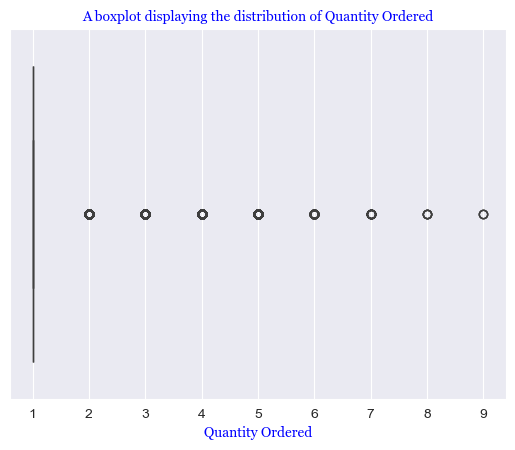

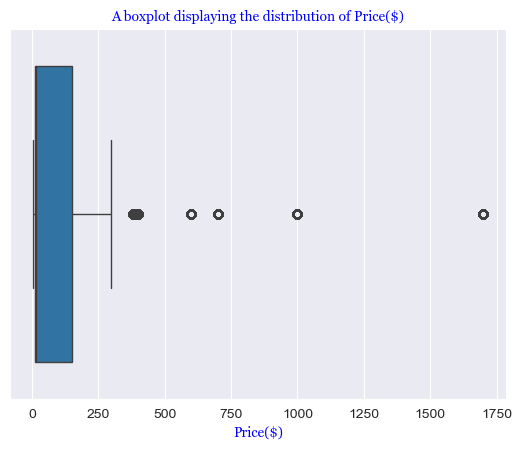

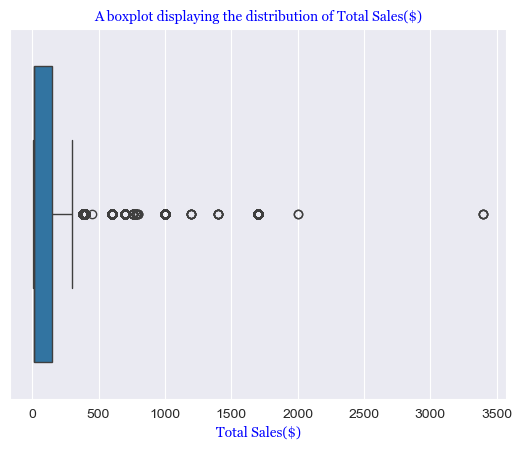

In [71]:
columns = ['Quantity Ordered',
       'Price($)', 'Total Sales($)']
for column in columns:
    sns.set_style('darkgrid')
    sns.boxplot(x = column, data = dataframe)
    plt.title(f'A boxplot displaying the distribution of {column}', fontdict = {'font':'Georgia'}, color = 'Blue')
    plt.xlabel(column, color = 'Blue', fontdict = {'font':'georgia'})
    plt.show()

### __Actionable Insights__
1. __The Quantity Ordered Boxplot:__ Majority of the customers purchase just one unit of the product per order and quantities higher than one are rare and treated as outliers in the distribution.

2. __The Price Boxplot:__  Most products are low priced since the interquatile range is tightly packed below $250 and this shows that 75% of the products are priced under 250 dollars. High priced products (products above 500 dollars) such as Macbooks , Iphones are outliers. The high priced products can significantly contribute to overall revenue despite being sold less frequently.

3. __The Total Sales Boxplot__:The majority of total sales per order are clustered below 500 dollars, indicating that customers typically purchase lower-cost items or small quantities.
However, a small number of orders generate much higher revenue, with some sales exceeding $3000, likely due to bulk purchases or high-priced products.

## __Phase 3: Report__

>__The highest Sales was made in December__

>__San Francisco Sold most products and it sold 50169 products in total__

>__Based on the data, the highest number of orders was made around 11:58AM and 1:25PM. Therefore, Scheduling advertisements shortly before these peak time such as 11:00AM - 1:00 PM would be most effective in maximizing customer purchases.__ 

>__While analyzing the data, i noticed a pattern where most customers that bought iphones also bought Lightning Charging Cable__

>__The most sold product is AAA Batteries (4-pack) and a total of 30986 units were sold thorughout the year. It is the most sold products due to the fact that it is the least expensive product. It costs 2.99 dollars__